# Decomposition - Leslie-Gower Population Dynamics Example

The following example is based on the dynamics of a general predator-prey system described by {cite}`bazykin1998` consisting of a set of ODEs.

$$
\begin{align}
\frac{dx_0}{dt} &= (r_1-a_1x_1-b_1x_0)x_0  \tag{1}\\
\frac{dx_1}{dt} &= (r_2 - a_2\frac{x_1}{x_0}) \tag{2}
\end{align}
$$

Here, $x_0(t)$ represents the evolution of the prey population, while $x_1(t)$ represents the predator. For this example, the constant parameters include: the intrinsic growth rate of prey and predator, $r_1=r_2=\frac{1}{5}$, the predation rate $a_1=\frac{1}{5}$, the intra-prey competition coefficient, $b_1=\frac{1}{10}$, and the predator food-scarcity (or Leslie Gower) coefficient, $a_2=\frac{1}{100}$.

We will assume that the predator population evolution rate, $r_2-a_2 \frac{x_1}{x_0}$, is unknown, and we would like to use a Neural Network to approximate the term. Written explicitly:

$$
\begin{align}
z(t) = r_2-a_2 \frac{x_1}{x_0} &= f_{NN}(x(t), \theta)  \tag{3} \\
\end{align}
$$

<!-- Additionally, we will assume knowledge of the Lyapunov function given below in order to improve generalization by imposing mechanistic path constraints during model training. While Lyapunov functions are not typically known when true system dynamics are not known, adding this path constraint is intended to demonstrate SiNDAE's robustness to complex constraints.

$$
\begin{align}
V(t) =\ln \left( \frac{x_0}{x^*_0} \right) +\frac{x^*_0}{x_0} + \frac{a_1x^*_0}{x_2} \left( \ln \left( \frac{x_1}{x^*_1} \right) + \frac{x^*_1}{x_1} \right) \tag{4}
\end{align}
$$

where $x^*_0=\frac{r_1a_2}{a_1r_2+a_2b_1}$ and $x^*_1=\frac{r_1r_2}{a_1r_2+a_2b_1}$.

This becomes part of the DAE system in the form of an inequality path constraint given by:

$$
\begin{align}
\frac{dV}{dt} \le 0 \tag{5}
\end{align}
$$ -->

Let's start with the required imports

In [1]:
%matplotlib inline

import logging
import jax
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

from sindae.nn_utils import SimpleMLP
from sindae import generate_data
from sindae.data_utils import extract_instance_data, InstanceData
from sindae.algorithms.smoother import solve_smoother
from sindae.algorithms.pretrain import PretrainConfig, pretrain_mlp
from sindae.algorithms.decomp.train import DecompConfig, train_decomp
from sindae.problem import ProblemDefinition
from sindae.algorithms.inference import solve_inference

from sindae.plot_utils import plot_instance_data, plot_training_history

jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logging.getLogger('pyomo').setLevel(logging.ERROR)
logging.getLogger('cyipopt').setLevel(logging.WARNING)
logger = logging.getLogger(__name__)

## Defining a Problem

As in [Four Tank Example](four_tank_example.ipynb), the Leslie Gower system should be defined as a class, inheriting from `ProblemDefinition` and implementing `build_trajectory()`, `get_input_vars()`, and `get_ouput_vars()`. In this example problem, we know the true dynamics of our problem (i.e. the $r_2 - a_2\frac{x_1}{x_0}$ dynamics), so the `true_constraints()` can be defined, allowing synthetic data generation and prediction comparison to the ground truth.

In [2]:
class LeslieGowerProblem(ProblemDefinition):
    def __init__(
        self,
        ## Additional Args ##
        params,
        lyap_descent,
        ## ProblemDefinition Args ##
        ics, 
        input_dim, 
        z_dim, 
        t_span, 
        nfe, 
        ncp, 
        obs_times = None, 
        obs_values = None, 
        obs_dim = None, 
        aux_vars_dim = None
    ):

        super().__init__(ics, input_dim, z_dim, 
                         t_span, nfe, ncp, obs_times, 
                         obs_values, obs_dim, aux_vars_dim)
        
        self.params = params
        self.lyap_descent = lyap_descent


    def build_trajectory(self, block: pyo.Block, traj_idx: int) -> None:
        t0, _ = self.t_span
        p     = self.params
        x0_ic = self.ics[traj_idx]

        denom = p['a1'] * p['r2'] + p['a2'] * p['b1']
        x0_ss = p['r1'] * p['a2'] / denom
        x1_ss = p['r1'] * p['r2'] / denom

        block.t    = dae.ContinuousSet(bounds=self.t_span)
        block.x    = pyo.Var(block.t, range(self.input_dim), initialize=1.0, within=pyo.NonNegativeReals)
        block.z    = pyo.Var(block.t, range(self.z_dim), initialize=0.0)
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)

        block.lyap_var = pyo.Var(block.t, initialize=1.0)
        block.dlyap_dt = dae.DerivativeVar(block.lyap_var, wrt=block.t)

        ## Differential Equations ##
        @block.Constraint(block.t, range(2))
        def diffeq(b, t, s):
            if s == 0:
                # Eqn (1)
                return b.dxdt[t, 0] == b.x[t, 0] * (p['r1'] - p['a1'] * b.x[t, 1] - p['b1'] * b.x[t, 0])
            else:
                # Eqn (2)
                return b.dxdt[t, 1] == b.x[t, 1] * b.z[t, 0] # z is the RHS of the equations to be learned by a NN


        ## Path Constraints (optional) ##
        @block.Constraint(block.t)
        def lyap_constr(b, t):
            # Eqn (4)
            return b.lyap_var[t] == (
                pyo.log(b.x[t, 0] / x0_ss) + x0_ss / b.x[t, 0]
                + (p['a1'] * x0_ss / p['a2'])
                * (pyo.log(b.x[t, 1] / x1_ss) + x1_ss / b.x[t, 1])
            )

        if self.lyap_descent:
            @block.Constraint(block.t)
            def lyap_descent_constr(b, t):
                if t == t0:
                    return pyo.Constraint.Skip
                # Eqn (5)
                return b.dlyap_dt[t] <= 0

        for j in range(2):
            block.x[t0, j].fix(float(x0_ic[j]))

    
    ## Ground Truth ##
    def add_true_output_constraints(self, block: pyo.Block) -> None:
        p = self.params

        @block.Constraint(block.t)
        def true_z(b, t):
            return b.z[t, 0] == p['r2'] - p['a2'] * b.x[t, 1] / b.x[t, 0]
        
        
    def get_input_vars(self, block, t):  
        return [block.x[t, j] for j in range(2)]
    
    def get_output_vars(self, block, t): 
        return [block.z[t, 0]]
    
    def get_aux_vars(self, block, t):    
        return [block.lyap_var[t]]

Defining the model's mechanistic parameters discussed above.

In [3]:
LG_PARAMS = {
    'a1': 0.2,      # a_1 = 1/5
    'a2': 0.01,     # a_2 = 1/100
    'r1': 0.2,      # r_1 = 1/5
    'r2': 0.2,      # r_1 = 1/5
    'b1': 0.1,      # b_1 = 1/10
}

SEED = 0

Next, define the initial conditions for the data generation from the ground truth (since this is a known example). In this example, we will train for only one trajectory and thus require only one $(x_0, x_1)$ state variable IC pair.

In [4]:
## Initial Conditions ##
LG_ICS = np.array([[1.0, 0.1]])     # traj_0: x_t0 = [x_0, x_1]

Next, define the observed variable state dimension, $x(t)$, the number of NN modeled variables, and $z(t)$. There are no algebraic variables, $y(t)$ in this problem.

In [5]:
## Problem dimensions ##
FT_STATE_DIM = 2     # NN input dim
FT_Z_DIM     = 1     # NN output dim


The timespan over which the model should be solved.

In [6]:
## Time span ##
T_SPAN = (0, 80)

Training discretization scheme. See [Four Tank Example](four_tank_example.ipynb) for more details.

In [7]:
## Discretization for data generation with true model ##
NFE_DATA  = 60
NCP_DATA  = 3

Now we can define the problem instance

In [8]:
## Define the problem instance ##
problem = LeslieGowerProblem(
    # Additional args
    params=LG_PARAMS,
    lyap_descent=False,
    # Probelem definition args
    ics=LG_ICS,
    input_dim=FT_STATE_DIM,
    z_dim=FT_Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_DATA, 
    ncp=NCP_DATA,
    obs_dim=FT_STATE_DIM,
    aux_vars_dim=None
    )


## Generating the Data

With the problem defined, we can use the `generate_data()` function to generate the synthetic training data.

In [9]:
## Added noise standard deviation ##
NOISE_STD = np.array([0.05, 0.05])

## Ground truth observation frequency ##
OBS_EVERY = 4

In [10]:
print('=== 1. Generating data ===')
true_data: InstanceData = generate_data(
    problem=problem, 
    noise_std=NOISE_STD, 
    obs_every=OBS_EVERY, 
    seed=SEED,
)

=== 1. Generating data ===


generate_data: ok / optimal


## Defining the Neural Network

Before pretraining, the NN used to estimate the $z(t)$ terms should be defined. SinDAE, comes equipped with a `SimpleMLP` class as an equinox MLP implementation, which we will be using for this example. To set up your own NN architecture, see [Neural Network Utilities](../api/nn_utils.md).

In [11]:
## Define the NN ##
mlp = SimpleMLP(
    in_size=problem.input_dim,
    out_size=problem.z_dim,
    widths=[16, 16],
    activations=[jax.nn.softplus] * 2,
    key=jax.random.PRNGKey(SEED),
)

## Pretraining the Neural Network 

With the NN defined, the smoothed problem (i.e. with $z(t)$ as a decision variable) can be solved for ($x_{init}, z_{init}$) pretraining pairs. For both the smoothed problem solution and the training, the discretization scheme will be changed to show SiNDAE's discretization flexibility.

In [12]:
## Discretization for the smoothed problem and training ##
NFE_TRAIN = 40
NCP_TRAIN = 3
SMOOTH_COEF = 1

# update the problem's discretization for training
problem.nfe = NFE_TRAIN
problem.ncp = NCP_TRAIN

## Solve the smoothed problem and extract the pretraining pairs ##
smoother_m = solve_smoother(problem, mlp, smooth_coef=SMOOTH_COEF)
smoother_data: InstanceData = extract_instance_data(problem, smoother_m)

=== Building smoother for 1 trajectories (smooth_coef=1) ===
  Smoother: ok / optimal


In [13]:
## Pretraining configuration ##
PT_EPOCHS = 200
PT_BS = 32
PT_REG_COEF = 1e-3

pretrain_config = PretrainConfig(
    epochs=PT_EPOCHS, 
    batch_size=PT_BS, 
    reg_coef=PT_REG_COEF
)

print('=== 3. Pretraining MLP ===')
mlp = pretrain_mlp(mlp, smoother_data, pretrain_config)

=== 3. Pretraining MLP ===


## Neural Network Training - Decomposition Approach 

Now, the problem is defined and the NN we are using to approximate $z(t)$ pretrained, the Hybrid DAE can be solved end to end using either the simultaneous or decomposition approach. For this example, we will be using the *decomposition* approach. 

To use SiNDAE's `solve_decomp()` function, a decomposition configuration must be defined. This specifies the Adam and KKT gradient hyperparameters. See [Decomposition Solver](../api/decomp.md) for the complete configuration options.

In [14]:
N_STEPS = 300
LR = 5e-3
INIT_SLACK_COEF = 1e1
REG_COEF = 1e-3

decomp_cfg = DecompConfig(
    n_steps               = N_STEPS,
    lr                    = LR,
    init_slack_coef       = INIT_SLACK_COEF,
    param_reg_coef        = REG_COEF,
)

The decomposition approach solves smaller sub problems with the chosen NLP backend (POUNCE by default; pass `backend='cyipopt'` to switch). Its convergence tolerance and maximum number of iterations can be specified as shown below. 

In [ ]:
SOLVER_TOL = 1e-6
SOLVER_MAX_ITER = 300

# NLP solver options for subproblem solutions
decomp_solver_opts = dict(
    tol=SOLVER_TOL,
    max_iter=SOLVER_MAX_ITER
    )

Now we can use SiNDAE's `train_decomp()` method to solve the model using the simultaneous approach.

In [ ]:
## Solve the problem using the decomposition approach ##
print('=== 4. Training (decomposition) ===')
trained_m, mlp, history = train_decomp(
    problem=problem, 
    mlp=mlp, 
    cfg=decomp_cfg,
    data=smoother_data, 
    smoother_model=smoother_m,
    solver_options=decomp_solver_opts,
)

# extract the results
trained_data: InstanceData = extract_instance_data(problem, trained_m)

## Plot Results


<Figure size 1920x1440 with 0 Axes>

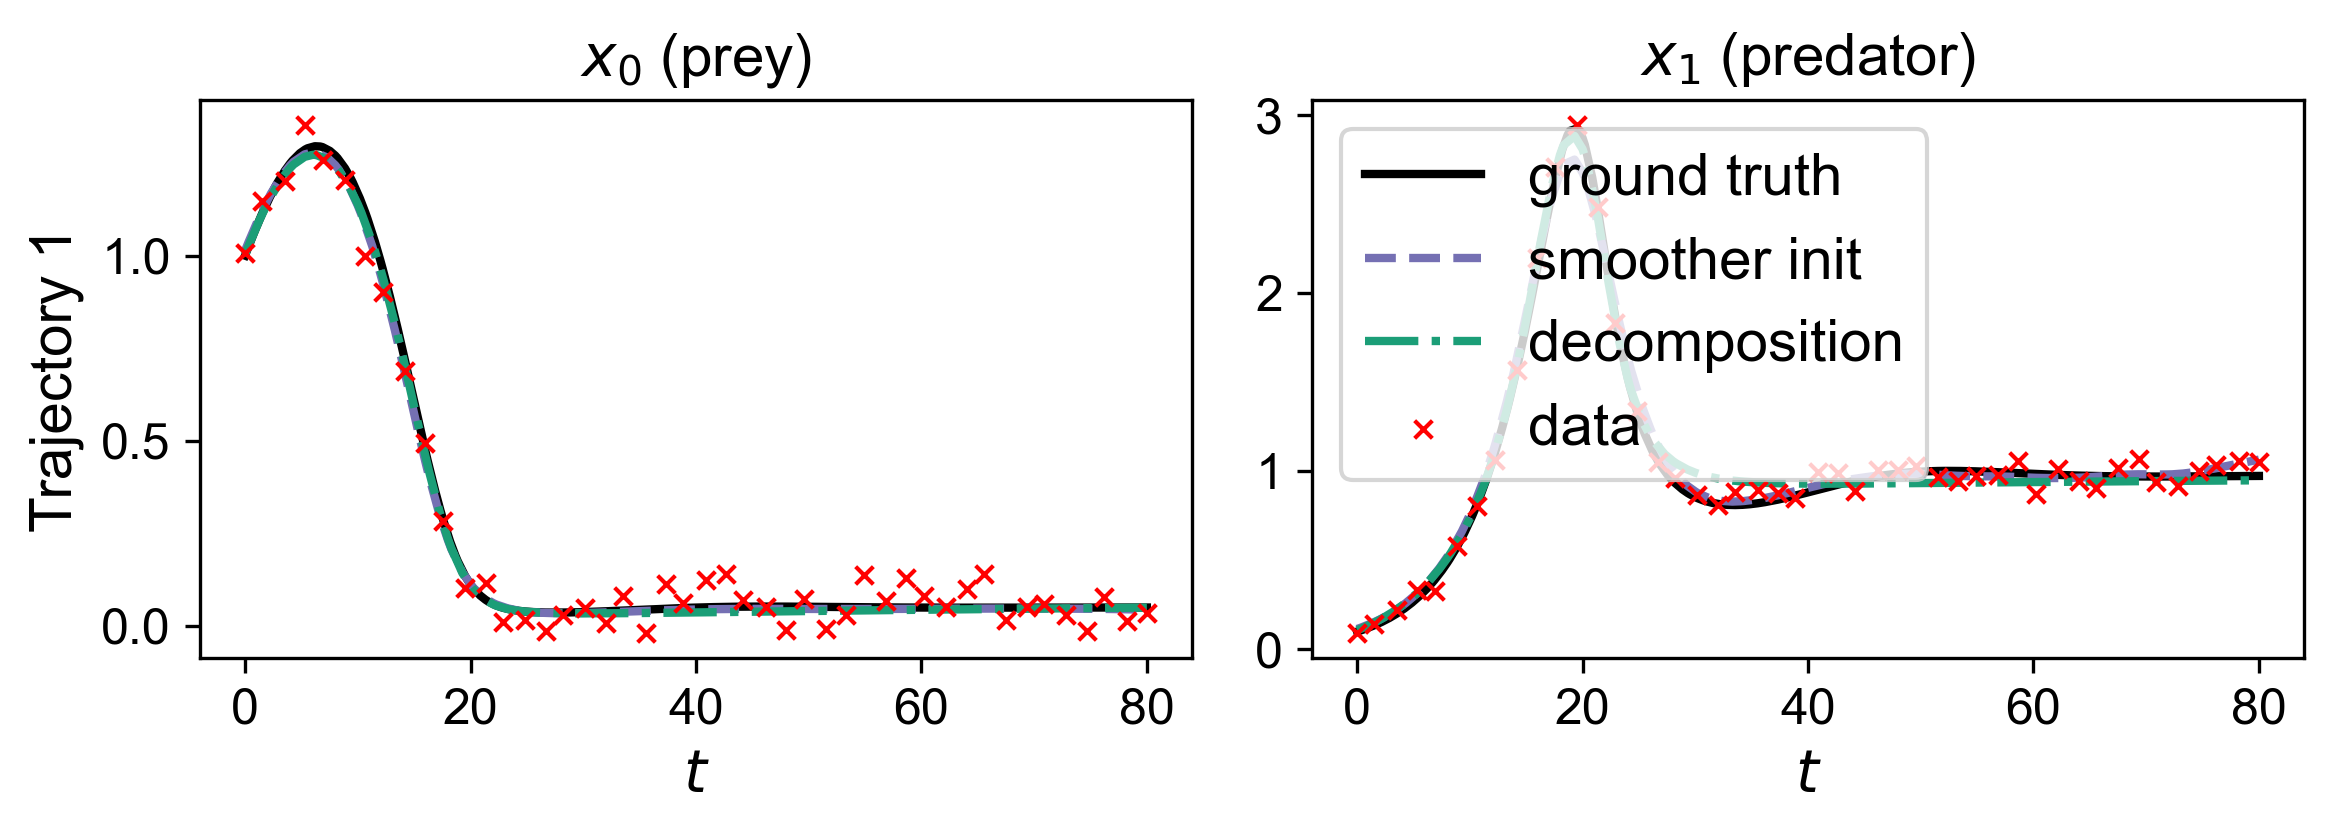

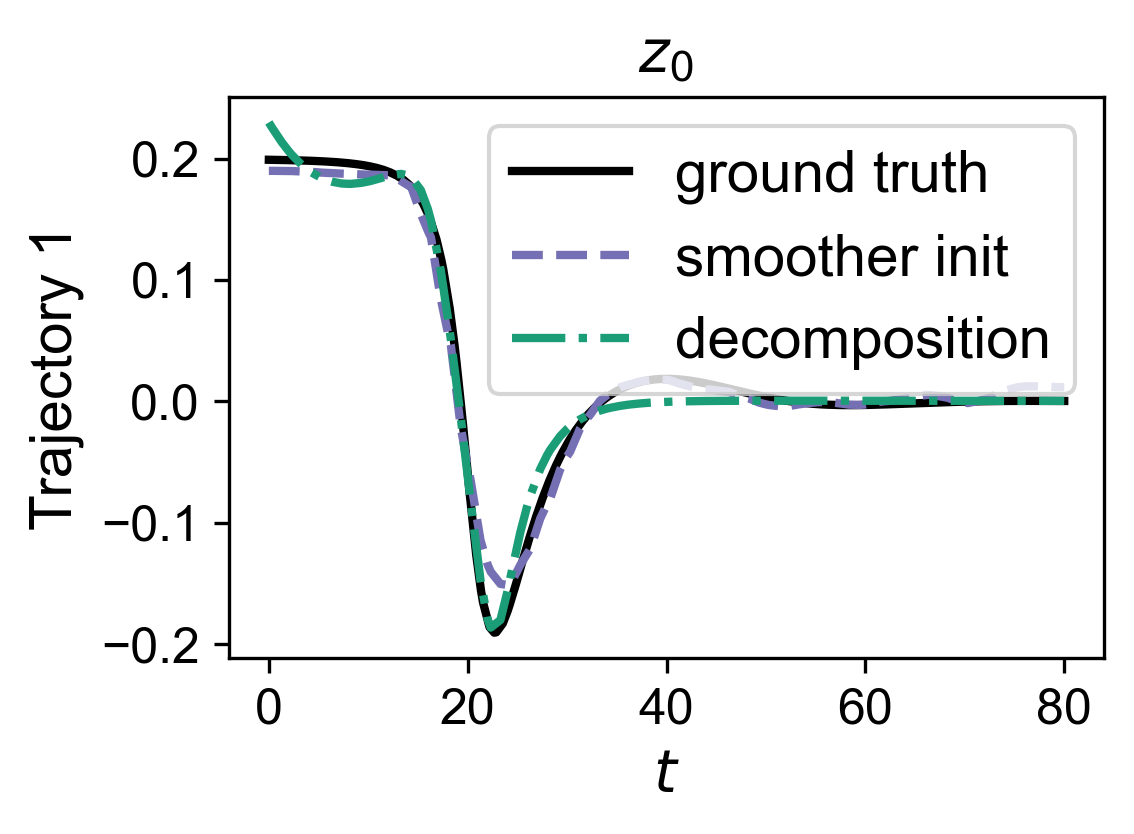

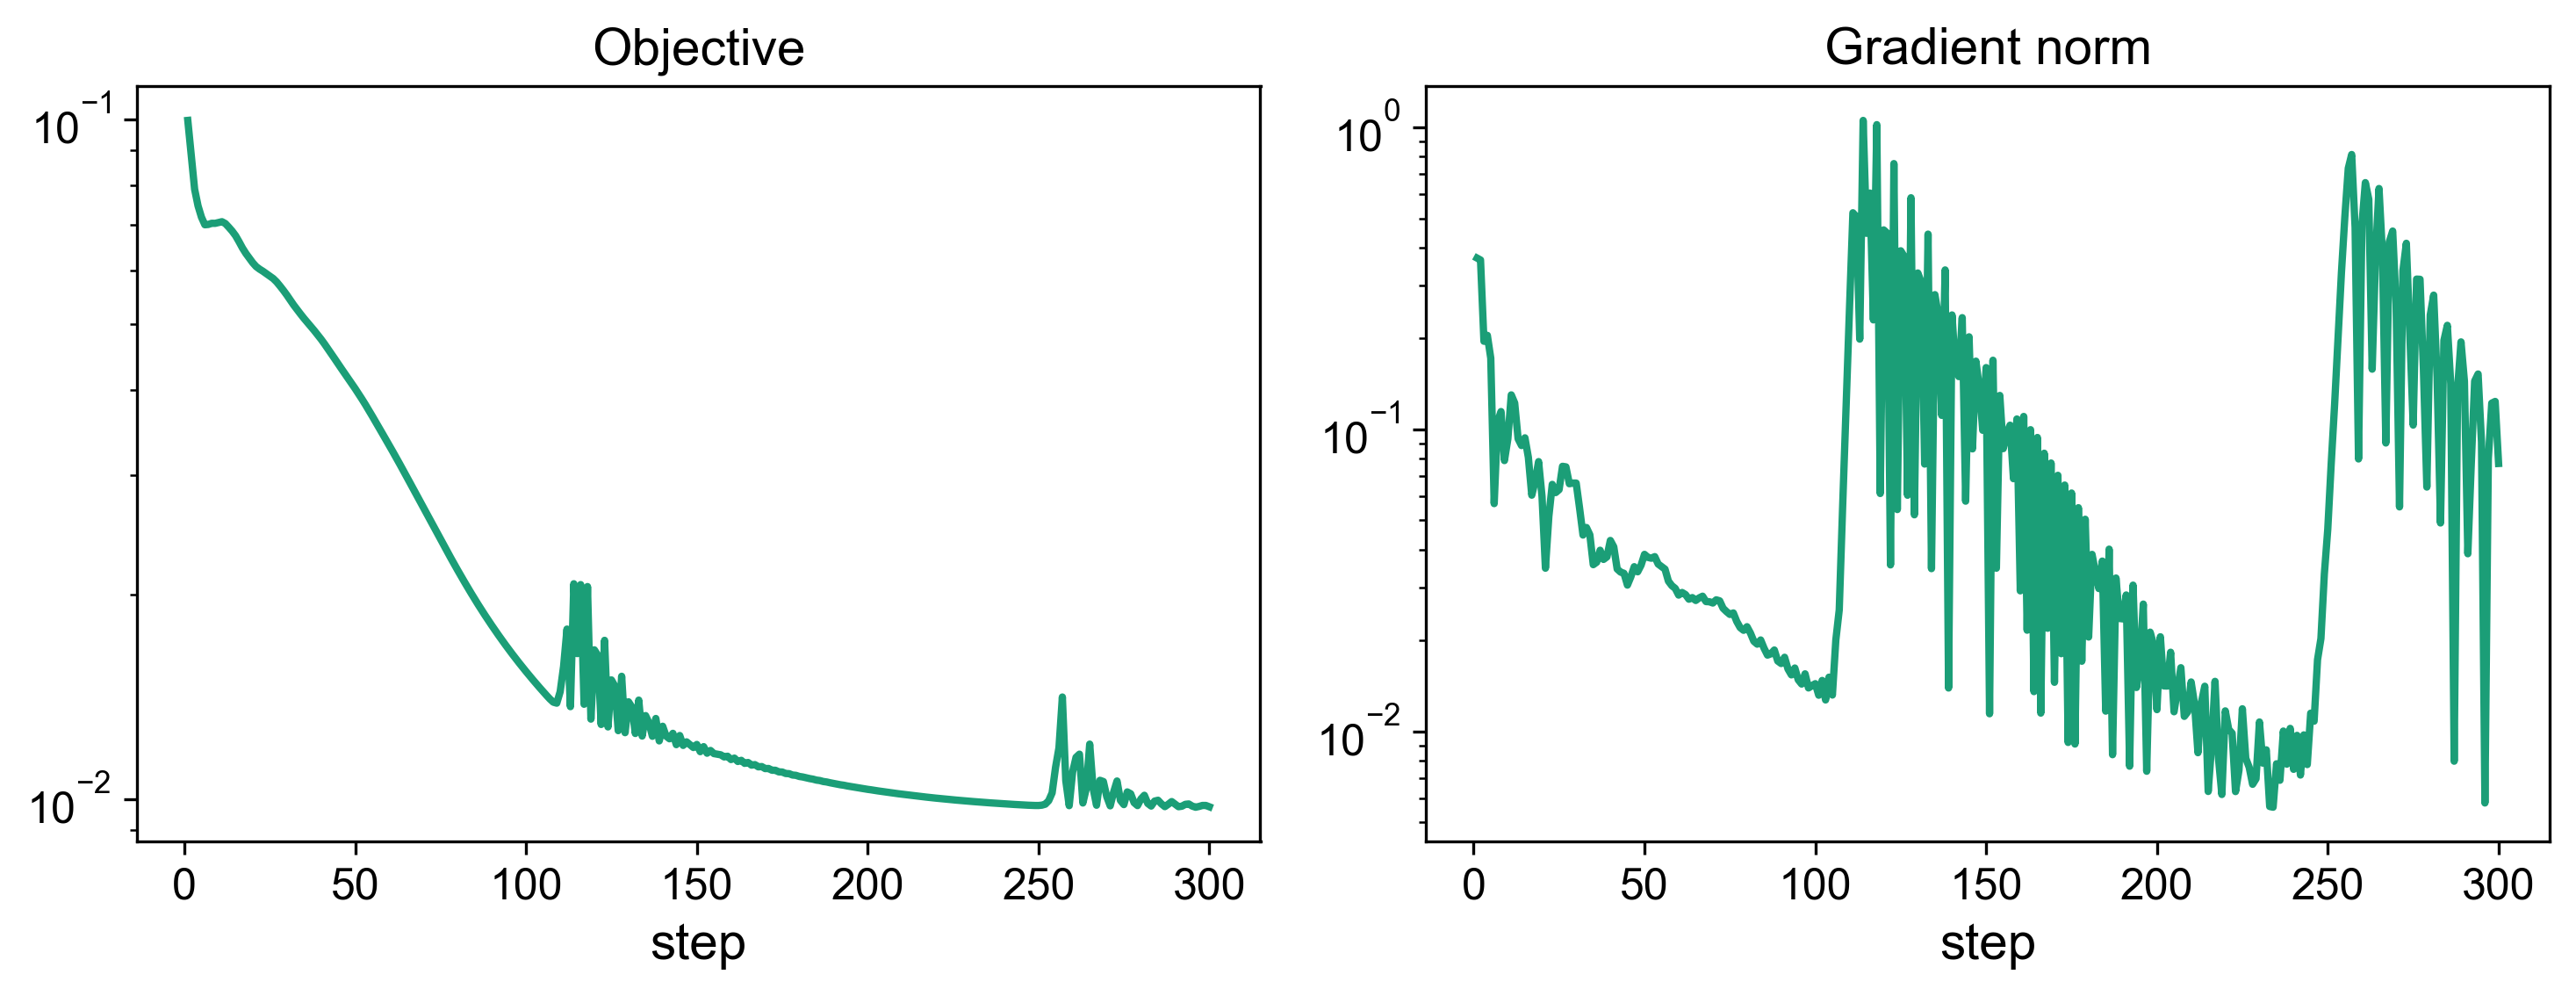

In [17]:
STATE_NAMES  = ['$x_0$ (prey)', '$x_1$ (predator)']
OUTPUT_NAMES = ['$z_0$']

datasets = [
    (true_data,     'ground truth',  {'color': 'black', 'ls': '-'}),
    (smoother_data, 'smoother init', {'color': 'C2',    'ls': '--'}),
    (trained_data,  'decomposition', {'color': 'C0',    'ls': '-.'}),
    ]

plt.figure()
fig_x, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    obs_times=problem.obs_times, obs_values=problem.obs_values,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
fig_z, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    groups=['outputs'], legend_placement='last',
)

fig_h, _ = plot_training_history(history)

plt.show()

## Inference using Trained Model

Now that the hybrid model is trained, we can use SiNDAE's inference function helper `solve_inference_model()` to predict trajectories given different initial conditions.

Accordingly, we can set new initial conditions for a new instance of the four tank problem defined above. Other parameters including: the number of discretization points, the number of collocation points, the time span, or the mechanistic parameters can also be altered before doing inference.

In [ ]:
## Validation Trajectory ICs##
LG_VAL_ICS = np.array([[5.0, 0.3]])  

# can also edit the discretization for demonstration
NFE_VAL = 20 
NCP_VAL = 2

val_problem = LeslieGowerProblem(
    # Additional args
    params=LG_PARAMS,
    lyap_descent=False,
    # ProblemDefinition args
    ics=LG_VAL_ICS,         # Validation ICs
    input_dim=FT_STATE_DIM,
    z_dim=FT_Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_VAL,            # Validation
    ncp=NCP_VAL,            # Validation
    obs_dim=FT_STATE_DIM,
    aux_vars_dim=None
    )

Since we know the ground truth dynamics for this problem, we can generate a ground truth trajectory to compare the inference result to. Of course, when making predictions on real problems, this is not usually possible. Here, the ground truth curve in intended to serve as a visual reference for hybrid model predictive capacity once trained.

A ground truth curve can be generated using the `generate_data()` function with `noise_std` set to 0 (for each dependent variable).

In [19]:
## Ground truth for visualisation ##
val_truth = generate_data(
    problem=val_problem, 
    noise_std=np.zeros(2),  # No added noise = ground truth
    obs_every=1,            # Observations = ground truth sampling
    seed=SEED)

generate_data: ok / optimal


Since the Neural Network is trained on data normalized by the mean and standard deviation of the observations, the training prediction data computed by `solve_simultaneous()` should be extracted by `extract_instance_data()` to produce an `InstanceData` object, before being passed to `solve_inference()`. In this example, the training instance data is held in the `trained_data` variable.

By default, `solve_inference()` will use POUNCE to solve the square problem with a hard equality constraint on the NN predictions (slack coefficient of 0.0). However, if this default leads to convergence difficulties, additional $\mathcal{l}_1$ slack can be added to loosen the constraint within reason. See [Inference](../api/inference.md) for more details.

In [20]:
## Solve the inference problem using trained model ## 
inference_m = solve_inference(
    problem=val_problem,
    mlp=mlp,
    data=trained_data,      # Training results for mean and std stats
    slack_coef=1e-5         # slack
)

## Extract the solution of the validation problem ##
val_results = extract_instance_data(val_problem, inference_m)

=== Building inference model for 1 trajectories (slack_coef=1e-05) ===
=== Solving inference model ===
  Inference: ok / optimal


Plotting, similar to above.

<Figure size 1920x1440 with 0 Axes>

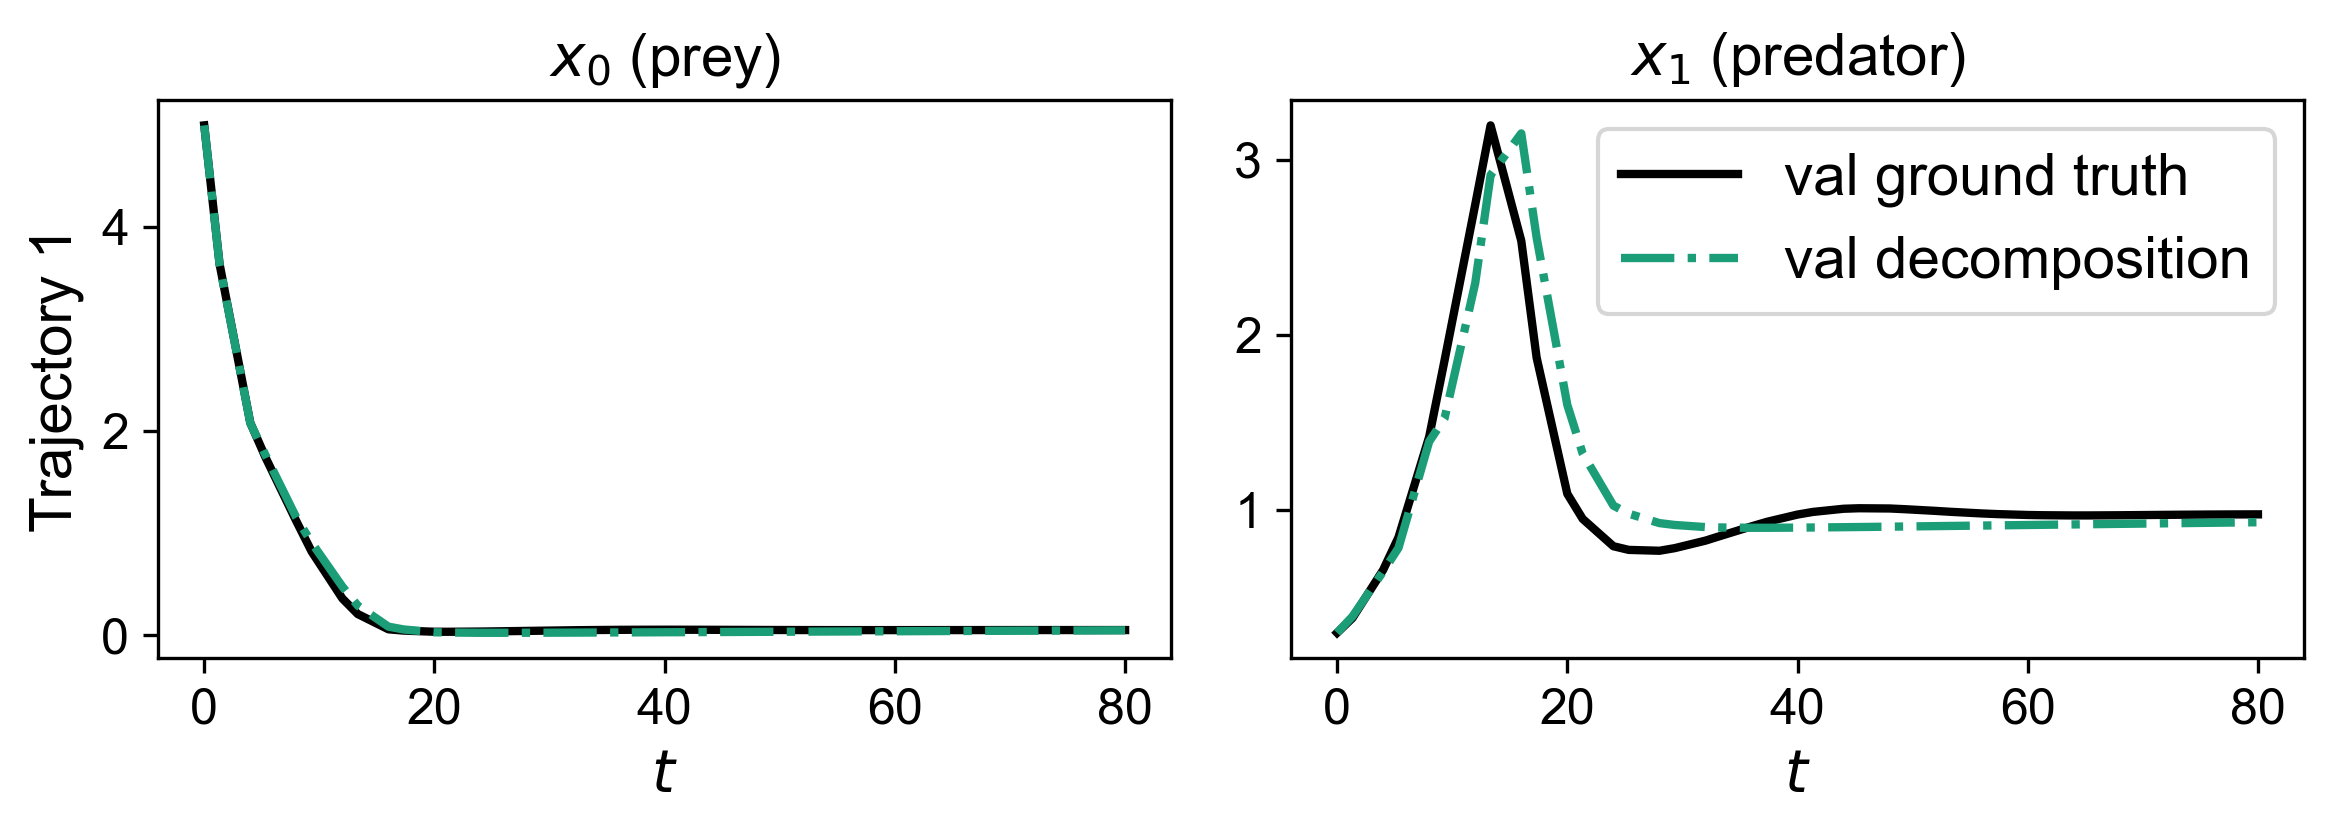

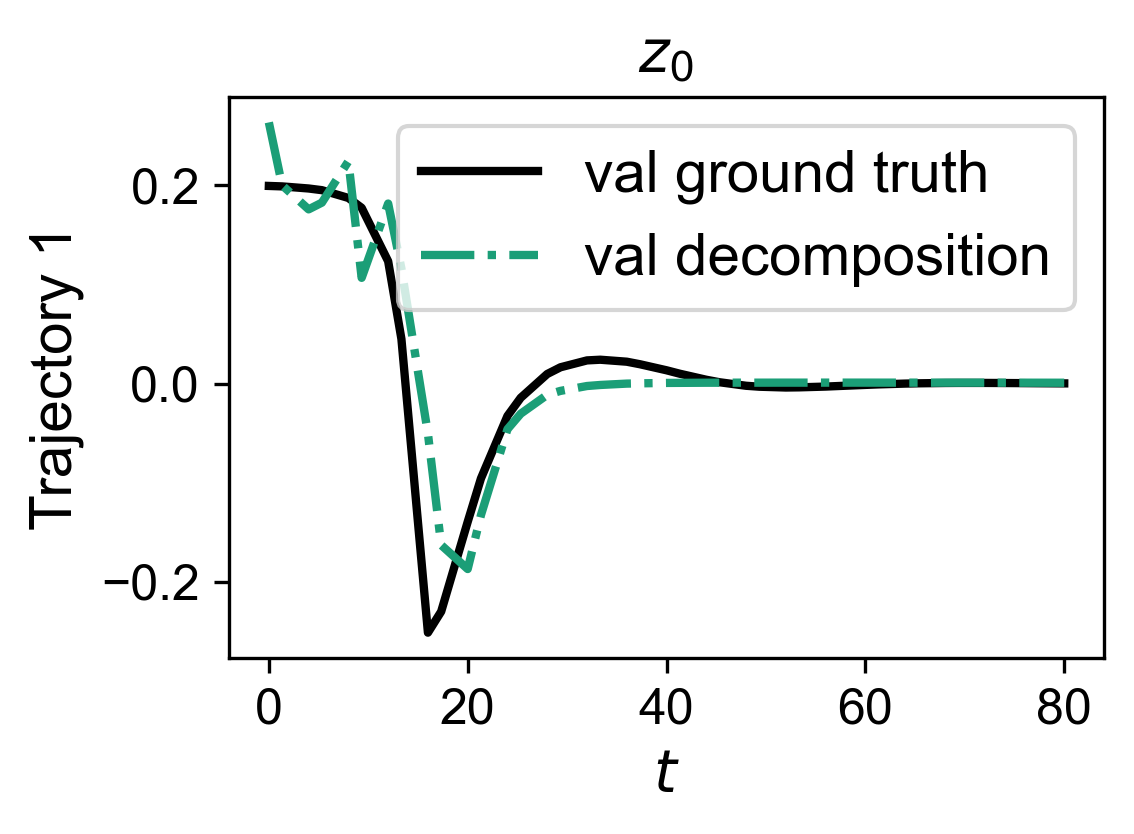

In [21]:
val_datasets = [
        (val_truth,     'val ground truth',  {'color': 'black', 'ls': '-'}),
        (val_results,   'val decomposition',  {'color': 'C0',    'ls': '-.'}),
    ]

plt.figure()
fig_x, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
fig_z, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    groups=['outputs'], legend_placement='last',
)

plt.show()

{cite}`lueg2025simultaneous`